### Imports

In [1]:
import warnings

import numpy as np
import torch
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch import nn

from src.audio_dataset import AudioDataset
from src.config import AUDIO_CONFIG
from src.engine import benchmark_snn, train_one_epoch_snn, validate_snn
from src.preprocessing import get_snn_pipeline, get_waveform_transformer, get_spectrogram_transformer
from src.snn_model import SNNAudioClassifier
from src.utils import get_random_audio, get_split_dataloaders

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [2]:
INPUT_DIR = 'data'
MODEL_PATH = 'models/best_cnn.pth'

# Hyperparameters
LR = 0.001
NUM_EPOCHS = 10
SLOPE = 25

### Setting up device to use

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Visualising encoded data

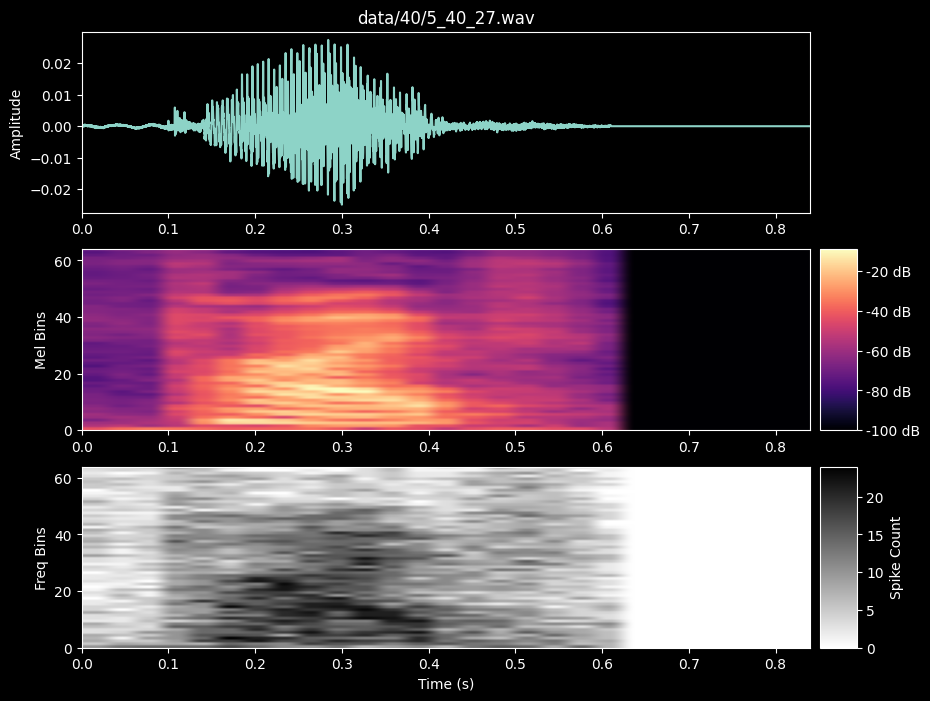

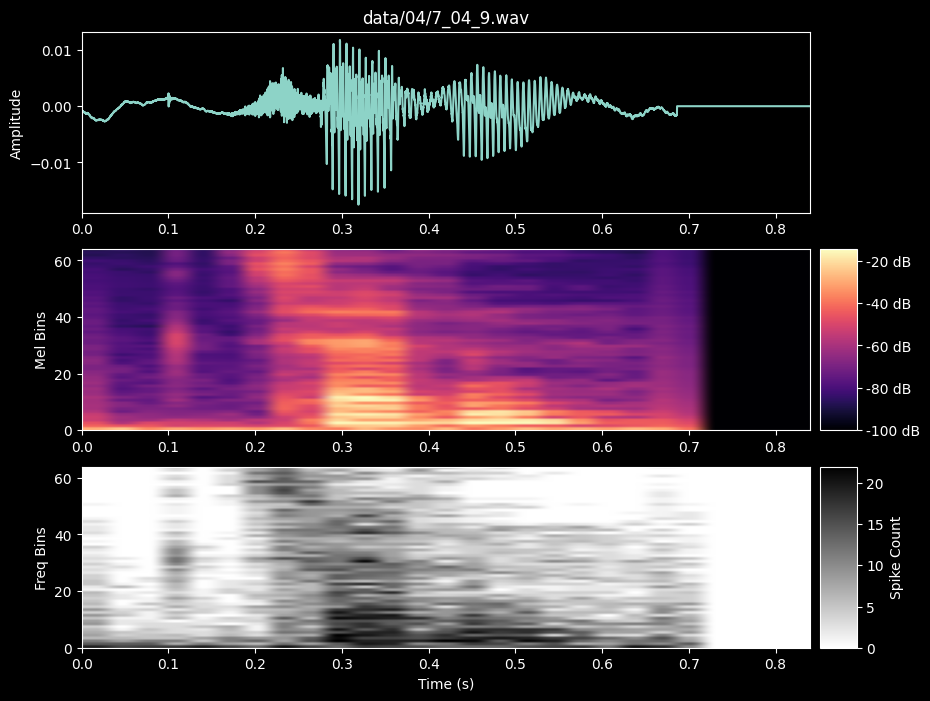

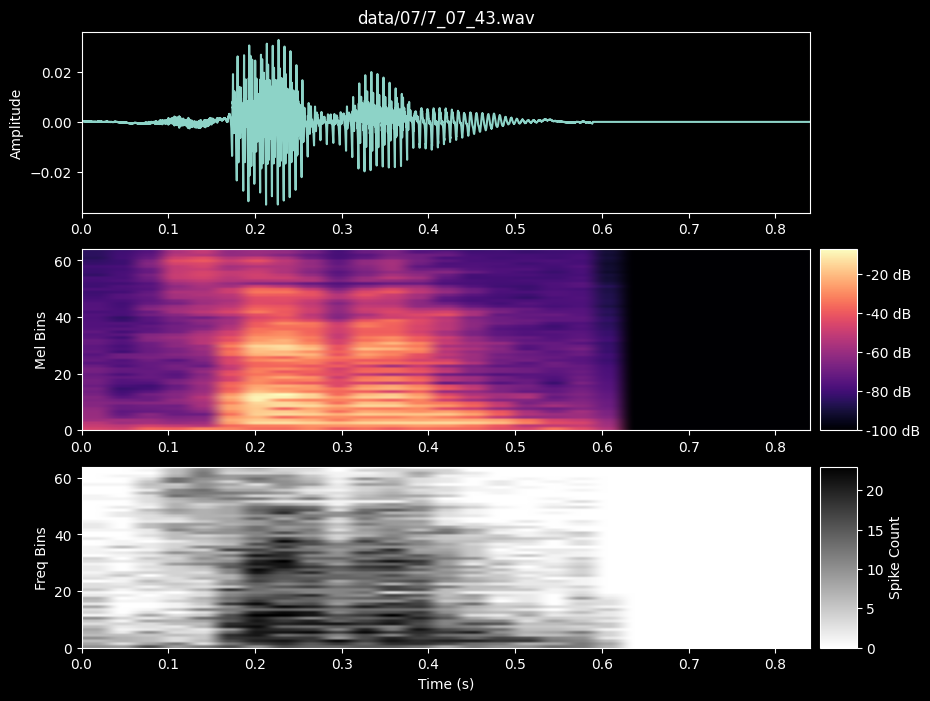

In [4]:
def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer()
    spectrogram_transformer = get_spectrogram_transformer()
    snn_pipeline = get_snn_pipeline()
    model = SNNAudioClassifier(slope=25)

    for i in range(3):
        file = get_random_audio(INPUT_DIR)

        raw_waveform, raw_sample_rate = torchaudio.load(file, normalize=True)
        new_waveform = waveform_transformer(raw_waveform)
        mel_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / AUDIO_CONFIG.target_sample_rate

        with torch.inference_mode():
            spikes = model.encoder(snn_pipeline(raw_waveform))

        spike_image = spikes.sum(dim=0).squeeze()

        # Plotting
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))

        # Waveform
        ax1.plot(np.linspace(0, new_duration, new_samples), new_waveform.t().numpy())
        ax1.set_title(file)
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes("right", size="5%", pad=0.1)
        cax1.axis("off")

        # Mel Spectrogram
        img2 = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, AUDIO_CONFIG.n_mels],
        )
        ax2.set_ylabel('Mel Bins')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img2, cax=cax2, format='%+2.0f dB')

        # Spikes
        img3 = ax3.imshow(
            spike_image.numpy(),
            origin='lower',
            aspect='auto',
            cmap='binary',
            extent=[0, new_duration, 0, AUDIO_CONFIG.n_mels],
        )
        ax3.set_ylabel('Freq Bins')
        ax3.set_xlabel('Time (s)')

        div3 = make_axes_locatable(ax3)
        cax3 = div3.append_axes("right", size="5%", pad=0.1)
        cbar3 = fig.colorbar(img3, cax=cax3, format='%d')
        cbar3.set_label('Spike Count')

        plt.show()

        display(Audio(data=new_waveform, rate=AUDIO_CONFIG.target_sample_rate))

visualise_audio_data()

### Training script

In [5]:
if __name__ == '__main__':
    dataset = AudioDataset(data_dir=INPUT_DIR, pipeline=get_snn_pipeline())
    train_dataloader, val_dataloader, test_dataloader = get_split_dataloaders(dataset)

    # Should have an extra dimension vs. the CNN for time at index 1
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    model = SNNAudioClassifier(slope=SLOPE).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    print("Training SNN...")
    best_accuracy = 0.0
    for epoch in range(NUM_EPOCHS):
        saved = False

        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')
        train_loss, train_accuracy = train_one_epoch_snn(device, model, criterion, optimizer, train_dataloader)
        val_loss, val_accuracy = validate_snn(device, model, criterion, val_dataloader)

        if val_accuracy > best_accuracy:
            saved = True
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_accuracy:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_accuracy:.2f}%')
        print()
    print(f'Best model had an accuracy of {best_accuracy:.2f}%.')
    print(f'Running final test:')

    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint, strict=True)

    test_accuracy = benchmark_snn(device, model, test_dataloader)
    print(f'Final test accuracy: {test_accuracy:.2f}%')

Features shape: torch.Size([64, 1, 64, 27])
Labels shape: torch.Size([64])

Training SNN...
[Epoch 1/10]


Validating: 100%|██████████| 47/47 [00:05<00:00,  8.21batches/s]


Train Loss: 1.61 | Train Accuracy: 46.73% | Val Loss: 0.96 | Val Accuracy: 70.67%

[Epoch 2/10]


Validating: 100%|██████████| 47/47 [00:02<00:00, 19.27batches/s]


Train Loss: 0.78 | Train Accuracy: 75.84% | Val Loss: 0.68 | Val Accuracy: 77.10%

[Epoch 3/10]


...

Train Loss: 0.20 | Train Accuracy: 94.05% | Val Loss: 0.23 | Val Accuracy: 93.37%

[Epoch 10/10]


Validating: 100%|██████████| 47/47 [00:02<00:00, 20.05batches/s]


Train Loss: 0.18 | Train Accuracy: 94.72% | Val Loss: 0.22 | Val Accuracy: 93.73%

Best model had an accuracy of 93.73%.
Running final test:


Benchmarking: 100%|██████████| 47/47 [00:05<00:00,  9.17batches/s]

Final test accuracy: 94.00%
